# 13) Mammoth Domain Cloud Fraction vs SW Ratio

Notebook 13 applies the Gothic-derived temperature-binned RGB threshold logic from Notebook 11 outputs to all GOES pixels in the Mammoth SW domain.

Main outputs:
- Pixel-level cloud mask (`cloud=1`, `clear=0`) per GOES timestamp.
- Domain cloud fraction time series (% cloudy pixels).
- Scatterplot of domain cloud fraction vs observed-to-clear-sky SW ratio.
- Exported CSV files and figures for downstream analysis.

## 1) Load Notebook 11 Threshold Outputs and Config

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Notebook 11 outputs and precomputed cloud-fraction CSV (built via PBS job)
TRAIN_TABLE_PATH = Path('/glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth/mammoth_rgb_sw_training_table_2024.csv')
CLOUD_FRACTION_CSV = Path('/glade/u/home/cdalden/goes_work/analysis/output_13_mammoth_domain_cloud_fraction/mammoth_domain_cloud_fraction_timeseries.csv')

OUT_DIR = Path('/glade/u/home/cdalden/goes_work/analysis/output_13_mammoth_domain_cloud_fraction')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Train table exists: {TRAIN_TABLE_PATH.exists()}')
print(f'Cloud-fraction CSV exists: {CLOUD_FRACTION_CSV.exists()}')
print(f'Output directory: {OUT_DIR}')

Train table exists: True
Cloud-fraction CSV exists: True
Output directory: /glade/u/home/cdalden/goes_work/analysis/output_13_mammoth_domain_cloud_fraction


## 2) Load GOES Pixel Data for Mammoth SW Domain

This step is executed in batch via PBS to avoid login-node memory limits.

Use:
- `analysis/build_mammoth_domain_cloud_fraction.py`
- `analysis/submit_mammoth_domain_cloud_fraction.pbs`

Then load the resulting CSV in this notebook.

In [2]:
if not CLOUD_FRACTION_CSV.exists():
    raise FileNotFoundError(
        f'Cloud-fraction CSV not found: {CLOUD_FRACTION_CSV}\n'
        'Run: qsub analysis/submit_mammoth_domain_cloud_fraction.pbs'
    )

cloud_frac_df = pd.read_csv(CLOUD_FRACTION_CSV, parse_dates=['time'])
cloud_frac_df['time'] = pd.to_datetime(cloud_frac_df['time'], errors='coerce').astype('datetime64[ns]')
cloud_frac_df = cloud_frac_df.dropna(subset=['time']).sort_values('time').reset_index(drop=True)

print(cloud_frac_df.head())
print('Cloud-fraction rows:', len(cloud_frac_df))

                 time  air_temp_c    model_bin  n_valid  n_cloudy  \
0 2024-01-02 00:02:30       -4.25  [-5.0, 0.0)     8030      7316   
1 2024-01-02 00:07:30       -4.25  [-5.0, 0.0)     8030      7286   
2 2024-01-02 00:12:30       -4.25  [-5.0, 0.0)     8030      7287   
3 2024-01-02 00:17:30       -4.25  [-5.0, 0.0)     8030      7259   
4 2024-01-02 00:22:30       -4.25  [-5.0, 0.0)     8030      7205   

   cloud_fraction_pct  
0           91.108344  
1           90.734745  
2           90.747198  
3           90.398506  
4           89.726027  
Cloud-fraction rows: 97056


## 3) Build Pixel-Level Cloud Mask from Gothic-Derived Thresholds

This is handled by the batch script `analysis/build_mammoth_domain_cloud_fraction.py`, which:
- trains temp-binned RGB models from Notebook 11b training output,
- applies them to all GOES pixels per timestamp,
- writes domain cloud-fraction results to CSV.

In [3]:
# Optional: inspect model-metadata exports from Notebook 11b
bin_metrics_path = Path('/glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth/mammoth_temp_bin_model_metrics.csv')
if bin_metrics_path.exists():
    bin_metrics_df = pd.read_csv(bin_metrics_path)
    print(bin_metrics_df[['temp_bin', 'n_rows', 'n_clear', 'n_cloudy', 'macro_f1', 'status']].head(12))
else:
    print(f'No bin-metrics CSV found at: {bin_metrics_path}')

         temp_bin  n_rows  n_clear  n_cloudy  macro_f1              status
0  [-15.0, -10.0)     117       11       106  1.000000             trained
1   [-10.0, -5.0)     450       44       406  0.688419             trained
2     [-5.0, 0.0)     679       64       615  0.440789             trained
3      [0.0, 5.0)    1157      248       909  0.735614             trained
4     [5.0, 10.0)    1654      545      1109  0.851343             trained
5    [10.0, 15.0)    2393      734      1659  0.900344             trained
6    [15.0, 20.0)    2844     1164      1680  0.938918             trained
7    [20.0, 25.0)     805      549       256  0.977496             trained
8    [25.0, 30.0)       2        2         0       NaN  skipped_low_sample


## 4) Compute Domain Cloud Fraction Time Series

Computed offline in PBS with

$$CF_t = 100 \times \frac{\sum \mathrm{cloud\_mask}_t}{N_{\mathrm{valid},t}}$$

and loaded from `mammoth_domain_cloud_fraction_timeseries.csv`.

In [4]:
# Domain cloud-fraction time series is already loaded as cloud_frac_df from the precomputed CSV.
# Keep only finite cloud-fraction rows for analysis.
cloud_frac_df = cloud_frac_df[np.isfinite(cloud_frac_df['cloud_fraction_pct'])].copy()
cloud_frac_df = cloud_frac_df.sort_values('time').reset_index(drop=True)

print(cloud_frac_df.head())
print('Finite cloud-fraction rows:', len(cloud_frac_df))

                 time  air_temp_c    model_bin  n_valid  n_cloudy  \
0 2024-01-02 00:02:30       -4.25  [-5.0, 0.0)     8030      7316   
1 2024-01-02 00:07:30       -4.25  [-5.0, 0.0)     8030      7286   
2 2024-01-02 00:12:30       -4.25  [-5.0, 0.0)     8030      7287   
3 2024-01-02 00:17:30       -4.25  [-5.0, 0.0)     8030      7259   
4 2024-01-02 00:22:30       -4.25  [-5.0, 0.0)     8030      7205   

   cloud_fraction_pct  
0           91.108344  
1           90.734745  
2           90.747198  
3           90.398506  
4           89.726027  
Finite cloud-fraction rows: 96327


## 5) Load Surface SW Observations and Clear-Sky Ideal

In [15]:
import xarray as xr

CUES_NC = Path('/glade/u/home/cdalden/goes_work/analysis/CUES_1min_data_atmos_radiation_soiltemp_precip_2015to2025.nc')
CUES_SW_VAR = 'downwelling_shortwave_platform'
CUES_CLEAR_REF_Q = 0.95

if not CUES_NC.exists():
    raise FileNotFoundError(f'CUES file not found: {CUES_NC}')

with xr.open_dataset(CUES_NC, decode_times=True) as ds:
    if CUES_SW_VAR not in ds.variables:
        raise KeyError(f'{CUES_SW_VAR} not found in {CUES_NC}')

    tname = None
    for cand in ['time', 'datetime']:
        if cand in ds.coords or cand in ds.variables:
            tname = cand
            break
    if tname is None:
        raise KeyError('No time coordinate found in CUES dataset.')

    sw_df = pd.DataFrame({
        'time': pd.to_datetime(ds[tname].values, errors='coerce'),
        'obs_sw': pd.to_numeric(ds[CUES_SW_VAR].values, errors='coerce'),
    })

# Keep all timesteps (including middle transmissivity values), then apply basic QC.
sw_df = sw_df.dropna(subset=['time', 'obs_sw']).copy()
sw_df = sw_df[sw_df['obs_sw'] >= 0].copy()

# Restrict to notebook target year to match cloud-fraction time series.
sw_df = sw_df[sw_df['time'].dt.year == 2024].copy()

# Build clear-sky ideal from minute-of-day upper quantile.
sw_df['minute_of_day'] = sw_df['time'].dt.hour * 60 + sw_df['time'].dt.minute
clear_ref = (
    sw_df.groupby('minute_of_day')['obs_sw']
    .quantile(CUES_CLEAR_REF_Q)
    .rename('clear_sky_sw')
    .reset_index()
)

sw_df = sw_df.merge(clear_ref, on='minute_of_day', how='left')
sw_df = sw_df.dropna(subset=['clear_sky_sw'])
sw_df = sw_df[sw_df['clear_sky_sw'] >= 20].copy()
sw_df = sw_df.sort_values('time').drop_duplicates('time').reset_index(drop=True)

print(sw_df[['time', 'obs_sw', 'clear_sky_sw']].head())
print('SW rows after QC (middle timesteps included):', len(sw_df))

                 time  obs_sw  clear_sky_sw
0 2024-01-01 07:16:00     0.1    434.309993
1 2024-01-01 07:17:00     0.5    437.525002
2 2024-01-01 07:18:00     1.0    440.010001
3 2024-01-01 07:19:00     1.5    442.799988
4 2024-01-01 07:20:00     2.0    445.824989
SW rows after QC (middle timesteps included): 260379


## 6) Compute SW Ratio ($\mathrm{SW_{obs}}/\mathrm{SW_{clear}}$)

In [16]:
with np.errstate(divide='ignore', invalid='ignore'):
    sw_df['sw_ratio'] = np.where(sw_df['clear_sky_sw'] > 0, sw_df['obs_sw'] / sw_df['clear_sky_sw'], np.nan)

# Keep only physically relevant range requested: include middle values, cut >1.
sw_df = sw_df[np.isfinite(sw_df['sw_ratio'])].copy()
sw_df = sw_df[(sw_df['sw_ratio'] >= 0.0) & (sw_df['sw_ratio'] <= 1.0)].copy()

print(sw_df[['time', 'obs_sw', 'clear_sky_sw', 'sw_ratio']].head())
print('SW ratio rows after <=1 filter:', len(sw_df))

                 time  obs_sw  clear_sky_sw  sw_ratio
0 2024-01-01 07:16:00     0.1    434.309993  0.000230
1 2024-01-01 07:17:00     0.5    437.525002  0.001143
2 2024-01-01 07:18:00     1.0    440.010001  0.002273
3 2024-01-01 07:19:00     1.5    442.799988  0.003388
4 2024-01-01 07:20:00     2.0    445.824989  0.004486
SW ratio rows after <=1 filter: 246897


## 7) Time-Align Cloud Fraction and SW Ratio

In [20]:
# Aggregate both series to the same fixed 5-minute window, then keep only overlapping windows.
window = '5min'

cloud_agg = (
    cloud_frac_df
    .set_index('time')
    .sort_index()
    .resample(window, label='right', closed='right')
    .agg({
        'cloud_fraction_pct': 'mean',
        'air_temp_c': 'mean',
        'n_valid': 'sum',
        'n_cloudy': 'sum',
    })
    .dropna(subset=['cloud_fraction_pct'])
    .reset_index()
    .rename(columns={'time': 'window_time'})
)

sw_agg = (
    sw_df[['time', 'sw_ratio', 'obs_sw', 'clear_sky_sw']]
    .set_index('time')
    .sort_index()
    .resample(window, label='right', closed='right')
    .mean()
    .dropna(subset=['sw_ratio'])
    .reset_index()
    .rename(columns={'time': 'window_time'})
)

analysis_df = (
    cloud_agg.merge(sw_agg, on='window_time', how='inner')
    .rename(columns={'window_time': 'time'})
    .dropna(subset=['cloud_fraction_pct', 'sw_ratio'])
    .sort_values('time')
    .reset_index(drop=True)
)

print(analysis_df.head())
print('Cloud windows:', len(cloud_agg))
print('SW windows:', len(sw_agg))
print('Overlapping merged windows:', len(analysis_df))

                 time  cloud_fraction_pct  air_temp_c  n_valid  n_cloudy  \
0 2024-01-02 07:20:00           63.586550       -4.25     8030      5106   
1 2024-01-02 07:25:00           62.739726       -4.25     8030      5038   
2 2024-01-02 07:30:00           62.291407       -4.25     8030      5002   
3 2024-01-02 07:35:00           61.444583       -4.25     8030      4934   
4 2024-01-02 07:40:00           61.295143       -4.25     8030      4922   

   sw_ratio  obs_sw  clear_sky_sw  
0  0.000449    0.20    445.824989  
1  0.004465    2.04    455.054003  
2  0.011404    5.36    469.290001  
3  0.017178    8.34    485.195000  
4  0.021168   10.62    501.445004  
Cloud windows: 96327
SW windows: 50634
Overlapping merged windows: 46097


## 8) Create Scatterplot and Fit Relationship

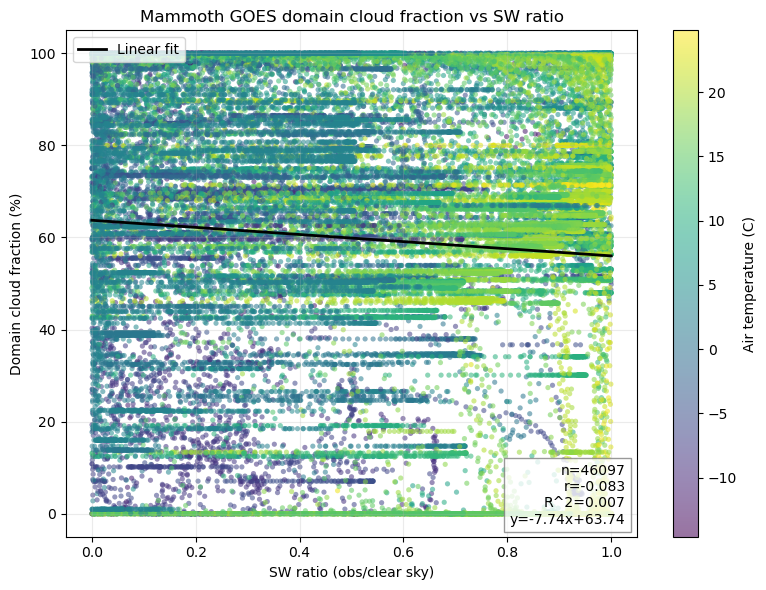

Saved scatter figure: /glade/u/home/cdalden/goes_work/analysis/output_13_mammoth_domain_cloud_fraction/mammoth_cloud_fraction_vs_sw_ratio_scatter.png


In [21]:
x = analysis_df['sw_ratio'].to_numpy(dtype=float)
y = analysis_df['cloud_fraction_pct'].to_numpy(dtype=float)

if len(analysis_df) < 3:
    raise ValueError('Not enough aligned rows for regression/scatter diagnostics.')

slope, intercept = np.polyfit(x, y, 1)
y_hat = slope * x + intercept
r = float(np.corrcoef(x, y)[0, 1])
r2 = float(r2_score(y, y_hat))

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(x, y, c=analysis_df['air_temp_c'], s=14, alpha=0.55, cmap='viridis', edgecolors='none')
xx = np.linspace(np.nanmin(x), np.nanmax(x), 200)
ax.plot(xx, slope * xx + intercept, color='black', lw=2.0, label='Linear fit')
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Air temperature (C)')

ax.set_xlabel('SW ratio (obs/clear sky)')
ax.set_ylabel('Domain cloud fraction (%)')
ax.set_title('Mammoth GOES domain cloud fraction vs SW ratio')
ax.grid(alpha=0.25)
ax.legend(loc='upper left')

stats_text = f'n={len(analysis_df)}\nr={r:.3f}\nR^2={r2:.3f}\ny={slope:.2f}x+{intercept:.2f}'
ax.text(0.98, 0.02, stats_text, transform=ax.transAxes, ha='right', va='bottom',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='0.5'))

scatter_png = OUT_DIR / 'mammoth_cloud_fraction_vs_sw_ratio_scatter.png'
fig.tight_layout()
fig.savefig(scatter_png, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved scatter figure: {scatter_png}')

## 9) Add Diagnostics and Export Notebook 13 Outputs

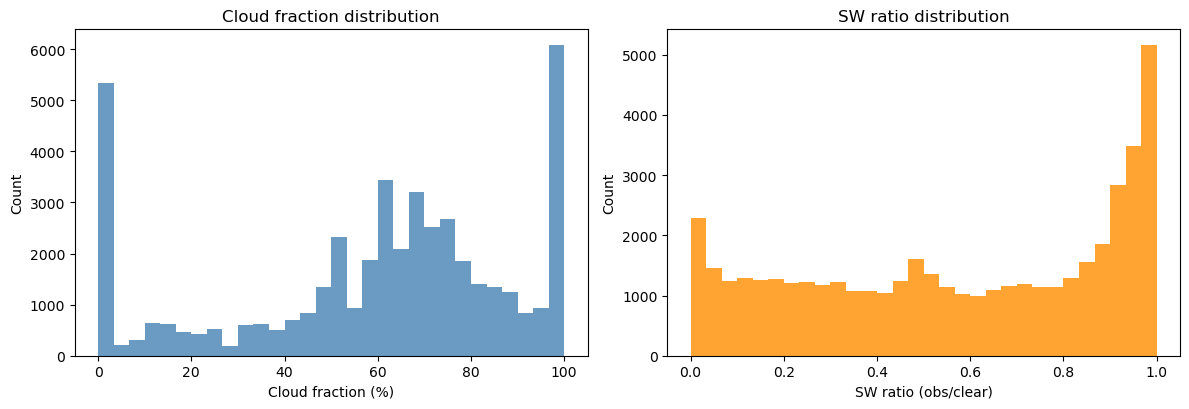

Saved cloud-fraction timeseries: /glade/u/home/cdalden/goes_work/analysis/output_13_mammoth_domain_cloud_fraction/mammoth_domain_cloud_fraction_timeseries.csv
Saved merged analysis table:    /glade/u/home/cdalden/goes_work/analysis/output_13_mammoth_domain_cloud_fraction/mammoth_cloud_fraction_vs_sw_ratio_merged.csv
Saved diagnostics histogram:    /glade/u/home/cdalden/goes_work/analysis/output_13_mammoth_domain_cloud_fraction/mammoth_cloud_fraction_sw_ratio_histograms.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(analysis_df['cloud_fraction_pct'], bins=30, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Cloud fraction (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Cloud fraction distribution')

axes[1].hist(analysis_df['sw_ratio'], bins=30, color='darkorange', alpha=0.8)
axes[1].set_xlabel('SW ratio (obs/clear)')
axes[1].set_ylabel('Count')
axes[1].set_title('SW ratio distribution')

fig.tight_layout()
dist_png = OUT_DIR / 'mammoth_cloud_fraction_sw_ratio_histograms.png'
fig.savefig(dist_png, dpi=200, bbox_inches='tight')
plt.show()

summary_df = analysis_df[['time', 'cloud_fraction_pct', 'n_valid', 'n_cloudy', 'air_temp_c', 'sw_ratio', 'obs_sw', 'clear_sky_sw']].copy()
cloudfrac_csv = OUT_DIR / 'mammoth_domain_cloud_fraction_timeseries.csv'
merged_csv = OUT_DIR / 'mammoth_cloud_fraction_vs_sw_ratio_merged.csv'

cloud_frac_df.to_csv(cloudfrac_csv, index=False)
summary_df.to_csv(merged_csv, index=False)

print(f'Saved cloud-fraction timeseries: {cloudfrac_csv}')
print(f'Saved merged analysis table:    {merged_csv}')
print(f'Saved diagnostics histogram:    {dist_png}')

## 10) Plot One Week of Mammoth SW, Clear Sky, and SW Cloud Flags (2024)

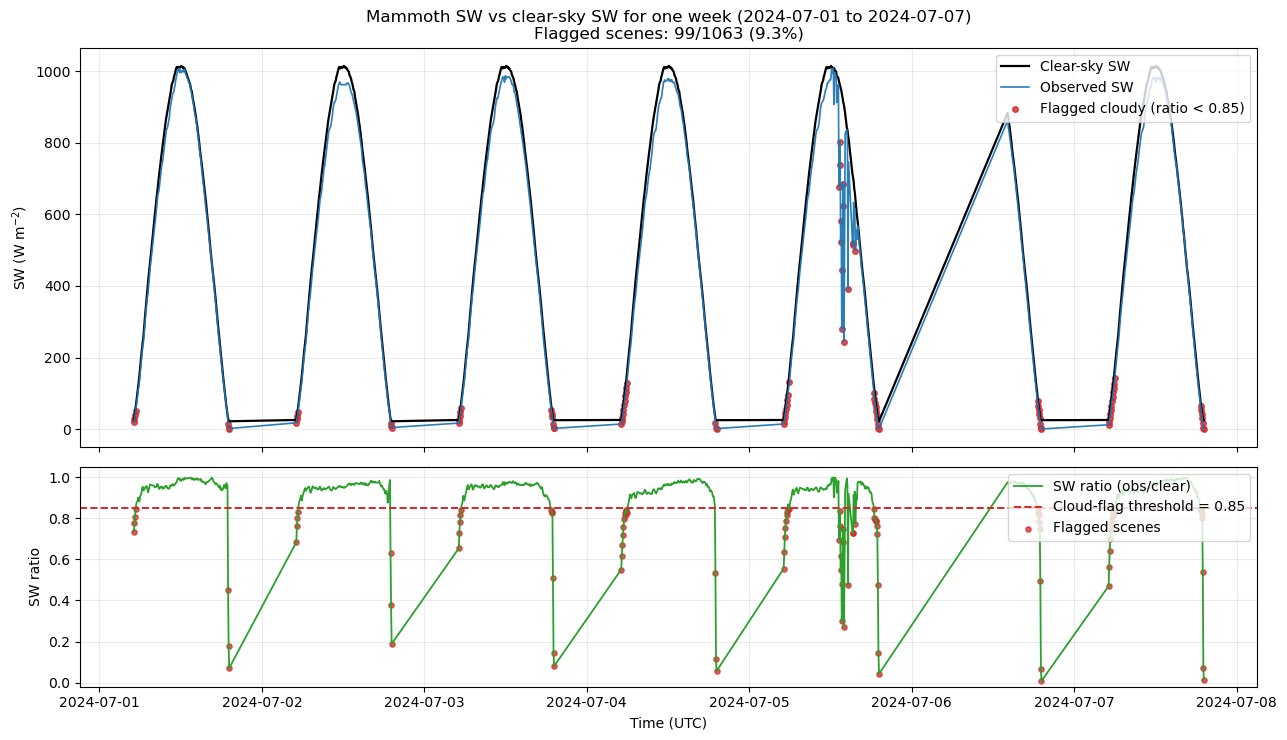

Week rows plotted: 1063
Flagged cloudy scenes: 99 (9.3%)
Saved weekly figure: /glade/u/home/cdalden/goes_work/analysis/output_13_mammoth_domain_cloud_fraction/mammoth_weekly_sw_clear_flag_20240701.png


In [23]:
# User-selectable week and SW cloud-flag threshold.
WEEK_START = pd.Timestamp('2024-07-01 00:00:00')
WEEK_END = WEEK_START + pd.Timedelta(days=7)
SW_CLOUDY_RATIO_THRESHOLD = 0.85

week_df = analysis_df[(analysis_df['time'] >= WEEK_START) & (analysis_df['time'] < WEEK_END)].copy()
if week_df.empty:
    raise ValueError(f'No overlapping SW/cloud windows found between {WEEK_START} and {WEEK_END}.')

week_df = week_df.sort_values('time').reset_index(drop=True)
week_df['sw_cloud_flag'] = week_df['sw_ratio'] < SW_CLOUDY_RATIO_THRESHOLD

n_total = len(week_df)
n_flagged = int(week_df['sw_cloud_flag'].sum())
pct_flagged = 100.0 * n_flagged / n_total

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 7.5), sharex=True, gridspec_kw={'height_ratios': [2.0, 1.1]}
)

# Top panel: observed SW and clear-sky SW.
ax1.plot(week_df['time'], week_df['clear_sky_sw'], color='black', lw=1.6, label='Clear-sky SW')
ax1.plot(week_df['time'], week_df['obs_sw'], color='tab:blue', lw=1.2, alpha=0.95, label='Observed SW')

# Highlight scenes flagged cloudy by SW ratio.
flag_df = week_df[week_df['sw_cloud_flag']]
ax1.scatter(
    flag_df['time'],
    flag_df['obs_sw'],
    s=16,
    color='tab:red',
    alpha=0.8,
    label=f'Flagged cloudy (ratio < {SW_CLOUDY_RATIO_THRESHOLD:.2f})',
)

ax1.set_ylabel('SW (W m$^{-2}$)')
ax1.set_title(
    f'Mammoth SW vs clear-sky SW for one week ({WEEK_START:%Y-%m-%d} to {(WEEK_END - pd.Timedelta(minutes=1)):%Y-%m-%d})'
    f'\nFlagged scenes: {n_flagged}/{n_total} ({pct_flagged:.1f}%)'
 )
ax1.grid(alpha=0.25)
ax1.legend(loc='upper right')

# Bottom panel: SW ratio with threshold and flagged markers.
ax2.plot(week_df['time'], week_df['sw_ratio'], color='tab:green', lw=1.3, label='SW ratio (obs/clear)')
ax2.axhline(
    SW_CLOUDY_RATIO_THRESHOLD,
    color='tab:red',
    lw=1.4,
    ls='--',
    label=f'Cloud-flag threshold = {SW_CLOUDY_RATIO_THRESHOLD:.2f}',
)
ax2.scatter(
    flag_df['time'],
    flag_df['sw_ratio'],
    s=14,
    color='tab:red',
    alpha=0.75,
    label='Flagged scenes',
)
ax2.set_ylabel('SW ratio')
ax2.set_ylim(-0.02, 1.05)
ax2.grid(alpha=0.25)
ax2.legend(loc='upper right')
ax2.set_xlabel('Time (UTC)')

week_png = OUT_DIR / f'mammoth_weekly_sw_clear_flag_{WEEK_START:%Y%m%d}.png'
fig.tight_layout()
fig.savefig(week_png, dpi=200, bbox_inches='tight')
plt.show()

print(f'Week rows plotted: {n_total}')
print(f'Flagged cloudy scenes: {n_flagged} ({pct_flagged:.1f}%)')
print(f'Saved weekly figure: {week_png}')